# Modelado y resolución de problemas combinatorios mediante QUBO

In [42]:
#Libraries
import dimod
import networkx as nx
import matplotlib.pyplot as plt
from dwave.samplers import SimulatedAnnealingSampler
import random
import numpy as np
from itertools import combinations
import itertools
import pickle
from IPython.display import Image
from collections import defaultdict

## Parte 1: Problema de partición de números

partimos de un conjunto de números enteros, que queremos repartir en 2 subgrupos: A y B, de forma que la diferencia entre las sumas de los números enteros de cada subgrupo sea mínima.

xi=1 si el número ai va al subgrupo A
xi=0 si va al B

queremos que SA-SB sea mínima.

In [47]:
def Qubo(a):
    Q = {}
    n = len(a)
    for i in range(n):
        Q[(i,i)] =  Q.get((i,i), 0.0) + 4*a[i]**2 - 4*sum(a)*a[i]
        for j in range(i+1,n):
            Q[(i,j)] = Q[(j,i)] =  Q.get((i,j), 0.0) + 4*a[i]*a[j]
           
    const = sum(a)**2
    return Q, const

In [3]:
a = [3,4,7]
Q, const = Qubo(a)
Q, const

({(0, 0): -132.0,
  (0, 1): 96.0,
  (1, 0): 96.0,
  (0, 2): 168.0,
  (2, 0): 168.0,
  (1, 1): -160.0,
  (1, 2): 224.0,
  (2, 1): 224.0,
  (2, 2): -196.0},
 196)

### Fuerza bruta

In [48]:
def E_original(a, x):
    """Energía original del problema."""
    return (sum(ai * (2*xi - 1) for ai, xi in zip(a, x)))**2


def fuerza_bruta(a):
    n = len(a)
    best_x = None
    best_E = float("inf")

    for x in itertools.product([0, 1], repeat=n): # genera todas las combinaciones posibles de ceros y unos
        E = E_original(a, x)
        if E < best_E:
            best_E = E
            best_x = x
            # va probando el valor de E y se asignan los valores de menor energia y la x que genera esa energia.

    A = [ai for ai, xi in zip(a, best_x) if xi == 1] # recorre los pares (ai,xi) obtenidos de zip(a,best_x). Si xi==1 añade ai a la lista A, si xi==0 a B.
    B = [ai for ai, xi in zip(a, best_x) if xi == 0]
    diff = abs(sum(A) - sum(B))
    
    print("=== Fuerza bruta (partición) ===")
    print("Bitstring óptimo       :", ''.join(str(bit) for bit in best_x))
    print("Subconjunto A      :", A, " (suma =", sum(A), ")")
    print("Subconjunto B      :", B, " (suma =", sum(B), ")")
    print("Diferencia |sumA-sumB|:", diff)
    print("Energía fuerza bruta, (Energía original)   :", best_E)
    
    return best_x, A, B, diff, best_E


In [5]:
a = [3,4,7]
fuerza_bruta(a)

=== Fuerza bruta (partición) ===
Bitstring óptimo       : 001
Subconjunto A      : [7]  (suma = 7 )
Subconjunto B      : [3, 4]  (suma = 7 )
Diferencia |sumA-sumB|: 0
Energía fuerza bruta, (Energía original)   : 0


((0, 0, 1), [7], [3, 4], 0, 0)

### Simulated Annealing

In [49]:
def simulated_annealing_particion(a,Q,const, num_reads=500):
    n = len(a)
    bqm = dimod.BinaryQuadraticModel.from_qubo(Q, offset=const) # añadimos offset=const para que tenga en cuenta la constante y obtengamos la misma energia que de la forma original.

    sampler = SimulatedAnnealingSampler() 
    sampleset = sampler.sample(bqm, num_reads=num_reads, beta_range=[0.1, 4.0], seed=123)
    
    best = sampleset.first
    sample = best.sample
    x = [sample[i] for i in range(n)] # para pasarlo a una lista ordenada
    
    E_qubo = best.energy
    E_orig = E_original(a, x) # para poder compararlas luego   
    
    A = [ai for ai, xi in zip(a, x) if xi == 1] # recorre los pares (ai,xi) obtenidos de zip(a,best_x). Si xi==1 añade ai a la lista A, si xi==0 a B.
    B = [ai for ai, xi in zip(a, x) if xi == 0]
    diff = abs(sum(A) - sum(B))
    
    print("=== Simulated Annealing (partición) ===")
    print("Bitstring óptimo       :", ''.join(str(bit) for bit in x))
    print("Subconjunto A      :", A, " (suma =", sum(A), ")")
    print("Subconjunto B      :", B, " (suma =", sum(B), ")")
    print("Diferencia |sumA-sumB|:", diff)
    print("Energía original   :", E_orig)
    print("Energía QUBO (BQM) :", E_qubo)
    
    return x, A, B, diff, E_orig, E_qubo

In [7]:
x, A, B, diff, E_orig, E_qubo = simulated_annealing_particion(a,Q,const, num_reads=500)

=== Simulated Annealing (partición) ===
Bitstring óptimo       : 001
Subconjunto A      : [7]  (suma = 7 )
Subconjunto B      : [3, 4]  (suma = 7 )
Diferencia |sumA-sumB|: 0
Energía original   : 0
Energía QUBO (BQM) : 0.0


### Comparar ambos resultados

In [51]:
# Datos de ejemplo
a = [3, 4, 7,5,11,2,9,32,21,9,5]

# Construir QUBO
Q, const = Qubo(a)

# Fuerza bruta
best_x_fb, A_fb, B_fb, diff_fb, E_fb = fuerza_bruta(a)

print()

# Simulated Annealing
x_sa, A_sa, B_sa, diff_sa, E_sa_orig, E_sa_qubo = simulated_annealing_particion(a, Q, const)

print()
print("=== Comparación ===")
print("Diferencia fuerza bruta  :", diff_fb)
print("Diferencia SA            :", diff_sa)
print("¿SA encontró el óptimo?  :", diff_sa == diff_fb)


=== Fuerza bruta (partición) ===
Bitstring óptimo       : 00001101010
Subconjunto A      : [11, 2, 32, 9]  (suma = 54 )
Subconjunto B      : [3, 4, 7, 5, 9, 21, 5]  (suma = 54 )
Diferencia |sumA-sumB|: 0
Energía fuerza bruta, (Energía original)   : 0

=== Simulated Annealing (partición) ===
Bitstring óptimo       : 00001101010
Subconjunto A      : [11, 2, 32, 9]  (suma = 54 )
Subconjunto B      : [3, 4, 7, 5, 9, 21, 5]  (suma = 54 )
Diferencia |sumA-sumB|: 0
Energía original   : 0
Energía QUBO (BQM) : 0.0

=== Comparación ===
Diferencia fuerza bruta  : 0
Diferencia SA            : 0
¿SA encontró el óptimo?  : True


### Visualizar los subconjuntos A y B y sus sumas. 

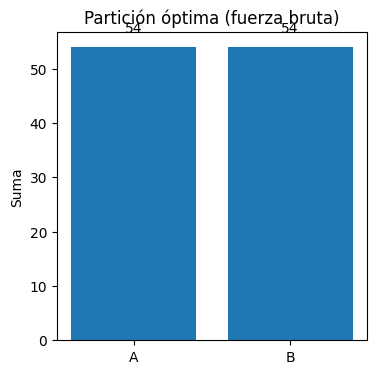

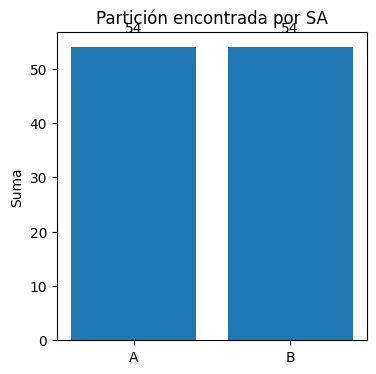

In [52]:
def plot_partition(A, B, title="Partición de números"):
    sums = [sum(A), sum(B)]
    labels = ['A', 'B']

    plt.figure(figsize=(4,4))
    plt.bar(labels, sums)
    plt.ylabel('Suma')
    plt.title(title)
    for i, v in enumerate(sums):
        plt.text(i, v + 0.05*max(sums), str(v), ha='center')
    plt.show()

# Visualizar la solución de fuerza bruta
plot_partition(A_fb, B_fb, title="Partición óptima (fuerza bruta)")

# Visualizar también la de SA
plot_partition(A_sa, B_sa, title="Partición encontrada por SA")


## Problema del viajante

### Conjunto de ciudades con coordenadas 2D

In [53]:
def crear_ciudades(n, seed=None):
    rng = np.random.default_rng(seed)
    # Cada ciudad es un punto (x, y) en [0,1] x [0,1]
    coords = rng.random((n, 2))
    return coords

In [11]:
coords = crear_ciudades(3)
coords

array([[0.01521876, 0.05609298],
       [0.74771031, 0.61982993],
       [0.12128009, 0.25510094]])

### Matriz de distancias

In [54]:
def matriz_distancias(coords):
    """
    Dado coords (n,2), calcula la matriz de distancias euclídeas D[i,j].
    """
    n = len(coords)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                D[i, j] = np.linalg.norm(coords[i] - coords[j])
            # Si quieres, puedes dejar D[i,i] = 0
    return D


In [13]:
coords = crear_ciudades(3)
D = matriz_distancias(coords)
coords, D

(array([[0.97544127, 0.31491903],
        [0.47460058, 0.08026164],
        [0.15952039, 0.32433317]]),
 array([[0.        , 0.55308724, 0.81597519],
        [0.55308724, 0.        , 0.39855543],
        [0.81597519, 0.39855543, 0.        ]]))

In [14]:
D.shape

(3, 3)

### QUBO con penalizaciones

In [55]:
def construir_qubo_tsp(D, lambda_ciudad=10.0, lambda_posicion=10.0):
    """
    Construye el QUBO del problema del viajante a partir de la matriz de distancias D.

    Devuelve:
      Q : defaultdict(float) con claves (a,b) donde a<=b, que representan
          los coeficientes del término x_a x_b.
    """
    n = D.shape[0]

    # Mapea (ciudad i, posición p) -> índice entero único
    def var_index(i, p):
        """
        i: ciudad (0..n-1)
        p: posición (0..n-1)
        """
        return i * n + p
    

    Q = defaultdict(float)

    # ---------------------------------------------------------
    # 1) Término de coste del recorrido:
    #    sum_{p,i,j} d_ij * x_{i,p} * x_{j,p+1}
    #    con p+1 tomado módulo n para cerrar el ciclo
    # ---------------------------------------------------------
    for p in range(n):
        p_next = (p + 1) % n  # siguiente posición, con vuelta al inicio
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue  # si no quieres permitir "quedarte en la misma ciudad"
                a = var_index(i, p)
                b = var_index(j, p_next)
                # QUBO suele ser simétrico, así que guardamos (min,max)
                if a <= b:
                    Q[(a, b)] += D[i, j]
                else:
                    Q[(b, a)] += D[i, j]

    # ---------------------------------------------------------
    # 2) Restricción: cada ciudad aparece exactamente una vez
    #    lambda_ciudad * sum_i ( sum_p x_{i,p} - 1 )^2
    # ---------------------------------------------------------
    for i in range(n):
        # variables de la ciudad i en todas las posiciones
        vars_ciudad = [var_index(i, p) for p in range(n)]

        # Expandimos (sum_p x_{i,p} - 1)^2
        # = -sum_p x_{i,p} + 2 sum_{p<q} x_{i,p} x_{i,q} + 1
        # (ignoramos la constante 1)
        # Términos lineales:
        for a in vars_ciudad:
            Q[(a, a)] += -lambda_ciudad

        # Términos cuadráticos:
        for idx1 in range(len(vars_ciudad)):
            a = vars_ciudad[idx1]
            for idx2 in range(idx1 + 1, len(vars_ciudad)):
                b = vars_ciudad[idx2]
                # coeficiente 2 * lambda_ciudad
                if a <= b:
                    Q[(a, b)] += 2.0 * lambda_ciudad
                else:
                    Q[(b, a)] += 2.0 * lambda_ciudad

    # ---------------------------------------------------------
    # 3) Restricción: cada posición está ocupada por una sola ciudad
    #    lambda_posicion * sum_p ( sum_i x_{i,p} - 1 )^2
    # ---------------------------------------------------------
    for p in range(n):
        # variables que ocupan la misma posición p en todas las ciudades
        vars_posicion = [var_index(i, p) for i in range(n)]

        # (sum_i x_{i,p} - 1)^2
        # = -sum_i x_{i,p} + 2 sum_{i<j} x_{i,p} x_{j,p} + 1
        # Términos lineales:
        for a in vars_posicion:
            Q[(a, a)] += -lambda_posicion

        # Términos cuadráticos:
        for idx1 in range(len(vars_posicion)):
            a = vars_posicion[idx1]
            for idx2 in range(idx1 + 1, len(vars_posicion)):
                b = vars_posicion[idx2]
                if a <= b:
                    Q[(a, b)] += 2.0 * lambda_posicion
                else:
                    Q[(b, a)] += 2.0 * lambda_posicion
   
    C = n * (lambda_ciudad + lambda_posicion)

    return Q, C


In [16]:
Q, C = construir_qubo_tsp(D, lambda_ciudad=10.0, lambda_posicion=10.0)
Q, C

(defaultdict(float,
             {(0, 4): np.float64(0.553087237064818),
              (0, 7): np.float64(0.8159751856372657),
              (1, 3): np.float64(0.553087237064818),
              (3, 7): np.float64(0.39855542913096176),
              (1, 6): np.float64(0.8159751856372657),
              (4, 6): np.float64(0.39855542913096176),
              (1, 5): np.float64(0.553087237064818),
              (1, 8): np.float64(0.8159751856372657),
              (2, 4): np.float64(0.553087237064818),
              (4, 8): np.float64(0.39855542913096176),
              (2, 7): np.float64(0.8159751856372657),
              (5, 7): np.float64(0.39855542913096176),
              (2, 3): np.float64(0.553087237064818),
              (2, 6): np.float64(0.8159751856372657),
              (0, 5): np.float64(0.553087237064818),
              (5, 6): np.float64(0.39855542913096176),
              (0, 8): np.float64(0.8159751856372657),
              (3, 8): np.float64(0.39855542913096176),
        

### Simulated Annealing

In [56]:
def decode_tour_from_sample(sample, n):
    """
    sample: dict índice->0/1 del BQM (índice = i*n + p) 
    devuelve: lista pi de longitud n con la ciudad en cada posición
    """
    # sample es un dicccionario que viene del sampler (simulated annealing) que te devuelve: claves (indices de variable, un entero a) y valores 0 o 1 (valor de esa variable)
    pi = [None] * n # crea lista pi de longitud n, pi[p] sera la ciudad que ocupa la posicion p
    for p in range(n):
        for i in range(n): # para cada posicion p recorre todas las ciudaddes i y calcula el valor de a 
            a = i * n + p
            if sample[a] == 1: # si la ciudad i está en la posición p
                pi[p] = i # guardamos el valor
                break # pasamos a la siguiente posición
    return pi
    # convierte el bitstring formato QUBO a una permutación de ciudades pi, a un tour humano, en cada posicion se encuentra la ciudad i [2,0,1] significa que la ciudad 2 se encuentra en la posicion 2 y se van recorriendo en ese orden.

def simulated_annealing_tsp(Q, C, n, num_reads=500):
    bqm = dimod.BinaryQuadraticModel.from_qubo(Q, offset=C)
    sampler = SimulatedAnnealingSampler()
    sampleset = sampler.sample(bqm, num_reads=num_reads,
                               beta_range=[0.1, 4.0], seed=123)
    best = sampleset.first
    sample = best.sample   # dict a->0/1
    E_qubo = best.energy
    # sample es un diccionario que viene del sampler (simulated annealaing) que contiene claves y valores

    pi = decode_tour_from_sample(sample, n) # convierte el bitstring a la permutacion de ciudades (el tour)
    x = np.array([sample[a] for a in range(n*n)], dtype=int) # vector binario plano de tamaño n*n

    return pi, x, E_qubo
    # pi : el tour encontrado por SA, las as que van de 0,1,2,4,5 
    # x : el bitstring que lo representa, 0: 0 0 0, 1: 0 0 1....
    # E_qubo : la energia QUBO 

In [19]:
n= len(a)
pi, x, E_qubo = simulated_annealing_tsp(Q, C, n, num_reads=500)
pi, x, E_qubo

([0, 2, 1], array([1, 0, 0, 0, 0, 1, 0, 1, 0]), np.float64(1.7676178518330516))

### Fuerza bruta

In [57]:
def build_x_from_pi(pi): # concepto inverso a decode_tour_from_sample, pi es un tour.
    n = len(pi)
    x = np.zeros(n * n, dtype=int) # queremos construir un vector binario x de longitud n*n
    for p, i in enumerate(pi):
        a = i*n+p # indice de la variable (i,p)
        x[a] = 1 # si la ciudad i está en la posición p. a = i*n+p
    return x
    # convierte un tour pi en un vector x siguiendo el mismo mapeo que usamos en QUBO

def energy_from_x(Q, x, C):
    E = C
    for (a, b), coeff in Q.items():
        E += coeff * x[a] * x[b]
    return E
    # definicion de QUBO: Qab * xa * xb, sin tener en cuenta la constante, que no afecta a la busqueda de minima energia
    # implementa la definición de energía QUBO para un x concreto, sumando todos los términos cuadráticos y la constante C.
    
def tour_length_from_pi(pi, D): # pi: tour, permutacion de las ciudades. D : matriz de distancias
    n = len(pi)
    L = 0.0
    for k in range(n): # k recorre 0....n-1
        i = pi[k] # ciudad actual
        j = pi[(k + 1) % n]  # ciudad siguiente (con vuelta al inicio)
        L += D[i, j] # definicion clasica del coste del problema del viajante, calcula la longitud real del tour en el espacio de ciudades
    return L

In [ ]:
from itertools import permutations

n = 10
coords = crear_ciudades(n, seed=123)
D = matriz_distancias(coords)
Q, C = construir_qubo_tsp(D, lambda_ciudad=50.0, lambda_posicion=50.0)

best_pi = None
best_L = float("inf")
best_E = float("inf")


for pi in permutations(range(n)): # da todos los tours posibles
    L = tour_length_from_pi(pi, D)     # longitud real del tour (la suma de distancias con la matriz D, es la energia original del problema)
    x = build_x_from_pi(pi) 
    E = energy_from_x(Q, x, C)         # energía QUBO (para ese mismo tour, usando Q y C)

    # se calcula L, x y E para todas las posibilidades de pi (todos los tours) ya que es fuerza bruta y con el if nos quedamos conn el de minima energia
    
    # Buscamos el tour de menor longitud
    if L < best_L:
        best_L = L
        best_pi = pi
        best_E = E
print("Mejor tour (TSP clásico):", best_pi)
print("Longitud mínima:", best_L)
print("Energía QUBO para ese tour:", best_E)
print("Número de términos en Q:", len(Q))

Mejor tour (TSP clásico): (0, 5, 1, 2, 4, 7, 9, 3, 8, 6)
Longitud mínima: 2.864357949330942
Energía QUBO para ese tour: 2.8643579493309517
Número de términos en Q: 1900


### Comparación de resultados

In [ ]:
# Ejecutar SA sobre el mismo problema
pi_sa, x_sa, E_sa = simulated_annealing_tsp(Q, C, n, num_reads=1000)
L_sa = tour_length_from_pi(pi_sa, D)

print("=== Fuerza bruta (TSP) ===")
print("Mejor tour         :", best_pi)
print("Longitud mínima    :", best_L)
print("Energía QUBO (fb)  :", best_E)
print()
print("=== Simulated Annealing (TSP) ===")
print("Tour encontrado    :", pi_sa)
print("Longitud SA        :", L_sa)
print("Energía QUBO (SA)  :", E_sa)
print()
print("¿SA encontró el óptimo? :", abs(L_sa - best_L) < 1e-6)


### Visualizar el recorrido óptimo en un gráfico


In [23]:
# Tour óptimo por fuerza bruta
plot_tour(coords, best_pi, title="Tour óptimo (fuerza bruta)")

# Tour encontrado por SA
plot_tour(coords, pi_sa, title="Tour encontrado por SA")


NameError: name 'plot_tour' is not defined

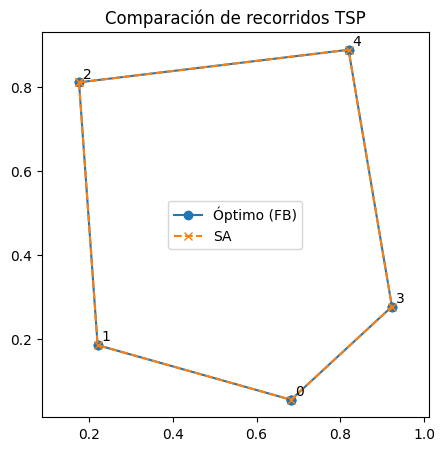

In [24]:
def plot_tours_compare(coords, pi_opt, pi_sa):
    plt.figure(figsize=(5,5))
    plt.scatter(coords[:,0], coords[:,1])
    for idx, (x, y) in enumerate(coords):
        plt.text(x + 0.01, y + 0.01, str(idx))

    # Óptimo
    xs_opt = [coords[i,0] for i in pi_opt] + [coords[pi_opt[0],0]]
    ys_opt = [coords[i,1] for i in pi_opt] + [coords[pi_opt[0],1]]
    plt.plot(xs_opt, ys_opt, marker='o', label='Óptimo (FB)')

    # SA
    xs_sa = [coords[i,0] for i in pi_sa] + [coords[pi_sa[0],0]]
    ys_sa = [coords[i,1] for i in pi_sa] + [coords[pi_sa[0],1]]
    plt.plot(xs_sa, ys_sa, marker='x', linestyle='--', label='SA')

    plt.title("Comparación de recorridos TSP")
    plt.axis('equal')
    plt.legend()
    plt.show()

plot_tours_compare(coords, best_pi, pi_sa)


In [25]:
import time
import itertools
import numpy as np
import dimod
from dwave.samplers import SimulatedAnnealingSampler

# --- Energía original (como ya tienes) ---
def E_original(a, x):
    return (sum(ai * (2*xi - 1) for ai, xi in zip(a, x)))**2

# --- QUBO correcto para partición ---
def Qubo_partition(a):
    """
    Construye Q y const para: E(x) = (Σ a_i (2x_i-1))^2
    Qii = 4 ai^2 - 4 S ai
    Qij = 8 ai aj (i<j)
    const = S^2
    """
    n = len(a)
    S = sum(a)
    Q = {}
    for i in range(n):
        Q[(i,i)] = Q.get((i,i), 0.0) + (4*a[i]**2 - 4*S*a[i])
        for j in range(i+1, n):
            Q[(i,j)] = Q.get((i,j), 0.0) + (8*a[i]*a[j])
    const = S**2
    return Q, const

# --- Energía QUBO (para comparar) ---
def E_qubo(Q, const, x):
    e = const
    for (i,j), v in Q.items():
        if i == j:
            e += v * x[i]
        else:
            e += v * x[i] * x[j]
    return float(e)

def check_partition_qubo(a, trials=20, seed=0):
    rng = np.random.default_rng(seed)
    Q, const = Qubo_partition(a)
    for _ in range(trials):
        x = rng.integers(0,2,size=len(a)).tolist()
        e1 = E_original(a, x)
        e2 = E_qubo(Q, const, x)
        # deberían coincidir (en teoría exacto)
        if abs(e1 - e2) > 1e-6:
            print("NO coincide para x=", x, "E_orig=", e1, "E_qubo=", e2)
            return False
    print("Check OK: E_original == E_QUBO (con const) en", trials, "tests")
    return True

# --- SA usando dimod (como el tuyo, pero compacto) ---
def sa_partition_dimod(a, Q, const, num_reads=500, seed=123):
    n = len(a)
    bqm = dimod.BinaryQuadraticModel.from_qubo(Q, offset=const)
    sampler = SimulatedAnnealingSampler()
    sampleset = sampler.sample(bqm, num_reads=num_reads, beta_range=[0.1, 4.0], seed=seed)

    best = sampleset.first
    sample = best.sample
    x = [sample[i] for i in range(n)]
    A = [ai for ai, xi in zip(a, x) if xi == 1]
    B = [ai for ai, xi in zip(a, x) if xi == 0]
    diff = abs(sum(A)-sum(B))
    return x, A, B, diff, float(best.energy)

# --- fuerza bruta (la tuya sirve; te dejo una versión que devuelve el óptimo) ---
def fuerza_bruta_partition(a):
    n = len(a)
    best_x = None
    best_E = float("inf")
    for x in itertools.product([0,1], repeat=n):
        E = E_original(a, x)
        if E < best_E:
            best_E = E
            best_x = list(x)
    A = [ai for ai, xi in zip(a, best_x) if xi == 1]
    B = [ai for ai, xi in zip(a, best_x) if xi == 0]
    diff = abs(sum(A)-sum(B))
    return best_x, A, B, diff, best_E

# --- medidas para preguntas (tiempo y tasa de éxito) ---
def measure_partition_limits(n_list=(8,10,12,14,16,18,20), trials_sa=50, num_reads=200, seed=0):
    rng = np.random.default_rng(seed)
    out = []

    for n in n_list:
        a = rng.integers(1, 51, size=n).tolist()
        Q, const = Qubo_partition(a)

        bf_E = None
        bf_t = None
        if n <= 24:
            t0 = time.perf_counter()
            _, _, _, _, bf_E = fuerza_bruta_partition(a)
            bf_t = time.perf_counter() - t0

        # SA repetido
        success = 0
        bestE = float("inf")
        t0 = time.perf_counter()
        for k in range(trials_sa):
            x, A, B, diff, Ebest = sa_partition_dimod(a, Q, const, num_reads=num_reads, seed=seed+1000+k)
            bestE = min(bestE, E_original(a, x))
            if bf_E is not None and abs(E_original(a, x) - bf_E) < 1e-9:
                success += 1
        sa_t = time.perf_counter() - t0

        out.append({
            "n": n,
            "bf_time": bf_t,
            "bf_E": bf_E,
            "sa_time_total": sa_t,
            "sa_best_E_found": bestE,
            "sa_success_rate": (success/trials_sa) if bf_E is not None else None
        })
    return out


In [26]:
a = [3,4,7]
Q, const = Qubo_partition(a)
check_partition_qubo(a)

best_x, A_fb, B_fb, diff_fb, E_fb = fuerza_bruta_partition(a)
x_sa, A_sa, B_sa, diff_sa, E_sa_qubo = sa_partition_dimod(a, Q, const, num_reads=500)

print("FB diff:", diff_fb, "E:", E_fb)
print("SA diff:", diff_sa, "E_orig:", E_original(a, x_sa), "E_bqm:", E_sa_qubo)
print("SA encontró óptimo?:", diff_sa == diff_fb)

print(measure_partition_limits())


Check OK: E_original == E_QUBO (con const) en 20 tests
FB diff: 0 E: 0
SA diff: 0 E_orig: 0 E_bqm: 0.0
SA encontró óptimo?: True


C:\Users\paula\AppData\Local\Temp\ipykernel_11488\3928746544.py:9: RuntimeWarning: overflow encountered in scalar add
  return (sum(ai * (2*xi - 1) for ai, xi in zip(a, x)))**2


[{'n': 8, 'bf_time': 0.0012859999987995252, 'bf_E': 1, 'sa_time_total': 0.9194315999993705, 'sa_best_E_found': np.int8(1), 'sa_success_rate': 1.0}, {'n': 10, 'bf_time': 0.005525499997020233, 'bf_E': 0, 'sa_time_total': 0.6913965000057942, 'sa_best_E_found': np.int8(0), 'sa_success_rate': 1.0}, {'n': 12, 'bf_time': 0.032835999998496845, 'bf_E': 0, 'sa_time_total': 1.0722361000007368, 'sa_best_E_found': np.int8(0), 'sa_success_rate': 1.0}, {'n': 14, 'bf_time': 0.12752550000004703, 'bf_E': 1, 'sa_time_total': 2.1967001000011805, 'sa_best_E_found': np.int8(1), 'sa_success_rate': 1.0}, {'n': 16, 'bf_time': 0.4310565999985556, 'bf_E': 0, 'sa_time_total': 1.060298700002022, 'sa_best_E_found': np.int8(0), 'sa_success_rate': 1.0}, {'n': 18, 'bf_time': 2.0561858999935794, 'bf_E': 1, 'sa_time_total': 0.9116886999981944, 'sa_best_E_found': np.int8(1), 'sa_success_rate': 1.0}, {'n': 20, 'bf_time': 12.242338800002472, 'bf_E': 0, 'sa_time_total': 1.5293707999953767, 'sa_best_E_found': np.int8(0), 'sa

In [27]:
def check_tsp_sample_feasible(sample, n):
    """
    sample: dict var->0/1
    Comprueba:
      - cada posición p tiene exactamente un 1 (una ciudad)
      - cada ciudad i aparece exactamente una vez
    """
    # matriz X[i,p]
    X = np.zeros((n,n), dtype=int)
    for i in range(n):
        for p in range(n):
            X[i,p] = int(sample[i*n + p])

    row_sums = X.sum(axis=1)  # por ciudad
    col_sums = X.sum(axis=0)  # por posición
    feasible = np.all(row_sums == 1) and np.all(col_sums == 1)
    return feasible, row_sums, col_sums

def decode_tour_safe(sample, n):
    feasible, row_sums, col_sums = check_tsp_sample_feasible(sample, n)
    if not feasible:
        return None, feasible, row_sums, col_sums

    pi = [None]*n
    for p in range(n):
        for i in range(n):
            if sample[i*n + p] == 1:
                pi[p] = i
                break
    return pi, feasible, row_sums, col_sums

def simulated_annealing_tsp_safe(Q, C, n, num_reads=500, seed=123):
    bqm = dimod.BinaryQuadraticModel.from_qubo(Q, offset=C)
    sampler = SimulatedAnnealingSampler()
    sampleset = sampler.sample(bqm, num_reads=num_reads, beta_range=[0.1, 4.0], seed=seed)

    best = sampleset.first
    sample = best.sample
    E_qubo = float(best.energy)

    pi, feasible, rs, cs = decode_tour_safe(sample, n)

    return pi, feasible, rs, cs, E_qubo

def measure_tsp_lambdas(D, lambda_list=(5,10,20,50,100,200), num_reads=500, seed=0):
    out = []
    n = D.shape[0]
    for lam in lambda_list:
        Q, C = construir_qubo_tsp(D, lambda_ciudad=lam, lambda_posicion=lam)
        t0 = time.perf_counter()
        pi, feasible, rs, cs, E = simulated_annealing_tsp_safe(Q, C, n, num_reads=num_reads, seed=seed+int(lam))
        dt = time.perf_counter() - t0

        L = None
        if feasible:
            L = tour_length_from_pi(pi, D)

        out.append({
            "lambda": lam,
            "time": dt,
            "feasible": feasible,
            "tour_len": L,
            "E_qubo": E
        })
    return out


In [28]:
n = 5
coords = crear_ciudades(n, seed=123)
D = matriz_distancias(coords)

Q, C = construir_qubo_tsp(D, lambda_ciudad=50.0, lambda_posicion=50.0)
pi, feasible, rs, cs, E = simulated_annealing_tsp_safe(Q, C, n, num_reads=1000, seed=123)

print("feasible:", feasible, "E:", E)
if feasible:
    print("pi:", pi, "L:", tour_length_from_pi(pi, D))
    plot_tour(coords, pi, title="Tour encontrado por SA (QUBO)")
else:
    print("No factible => sube lambda o num_reads")
    print("row_sums:", rs, "col_sums:", cs)

print(measure_tsp_lambdas(D))


feasible: True E: 2.70808707278934
pi: [2, 4, 3, 0, 1] L: 2.7080870727843926


NameError: name 'plot_tour' is not defined

In [29]:
import time
import math
import numpy as np
import itertools
import matplotlib.pyplot as plt
import dimod
from dwave.samplers import SimulatedAnnealingSampler

def timed_call(fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    t1 = time.perf_counter()
    return out, (t1 - t0)

def plot_curve(x, y, title, xlabel, ylabel, logy=False):
    plt.figure()
    plt.plot(x, y, marker='o')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if logy:
        plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.show()


In [30]:
def E_original(a, x):
    return (sum(ai*(2*xi-1) for ai, xi in zip(a, x)))**2

def fuerza_bruta_partition(a):
    n = len(a)
    best_x = None
    best_E = float("inf")
    for x in itertools.product([0,1], repeat=n):
        E = E_original(a, x)
        if E < best_E:
            best_E, best_x = E, list(x)
    return best_x, best_E

def Qubo_partition(a):
    n = len(a)
    S = sum(a)
    Q = {}
    for i in range(n):
        Q[(i,i)] = Q.get((i,i), 0.0) + (4*a[i]**2 - 4*S*a[i])
        for j in range(i+1, n):
            Q[(i,j)] = Q.get((i,j), 0.0) + (8*a[i]*a[j])  # OJO: 8
    const = S**2
    return Q, const

def sa_partition_dimod(a, Q, const, num_reads=500, seed=0):
    n = len(a)
    bqm = dimod.BinaryQuadraticModel.from_qubo(Q, offset=const)
    sampler = SimulatedAnnealingSampler()
    ss = sampler.sample(bqm, num_reads=num_reads, beta_range=[0.1, 4.0], seed=seed)
    best = ss.first.sample
    x = [best[i] for i in range(n)]
    return x, float(ss.first.energy)


In [41]:
def partition_scaling_experiment(
    n_list=range(6, 50, 2),
    trials_sa=20,
    num_reads=100,
    time_limit=5.0,
    seed=0
):
    rng = np.random.default_rng(seed)
    rows = []

    for n in n_list:
        a = rng.integers(1, 51, size=n).tolist()
        Q, const = Qubo_partition(a)

        # Brute force (si se pasa de time_limit, lo consideramos "imposible")
        bf_E = None
        bf_time = None
        bf_possible = True
        t0 = time.perf_counter()
        try:
            _, bf_E = fuerza_bruta_partition(a)
            bf_time = time.perf_counter() - t0
            if bf_time > time_limit:
                bf_possible = False
        except Exception:
            bf_possible = False

        if not bf_possible:
            bf_E, bf_time = None, None

        # SA repetido
        sa_times = []
        sa_Es = []
        success = 0
        best_gap = None

        for k in range(trials_sa):
            (x_sa, e_bqm), dt = timed_call(sa_partition_dimod, a, Q, const, num_reads, seed + 1000*k)
            e_orig = E_original(a, x_sa)
            sa_times.append(dt)
            sa_Es.append(e_orig)

            if bf_E is not None and abs(e_orig - bf_E) < 1e-9:
                success += 1

        sa_best = float(np.min(sa_Es))
        sa_mean = float(np.mean(sa_Es))
        sa_time_mean = float(np.mean(sa_times))

        if bf_E is not None:
            best_gap = sa_best - bf_E

        rows.append({
            "n": n,
            "bf_time": bf_time,
            "bf_E": bf_E,
            "sa_time_mean": sa_time_mean,
            "sa_best_E": sa_best,
            "sa_mean_E": sa_mean,
            "sa_success_rate": (success / trials_sa) if bf_E is not None else None,
            "sa_best_gap": best_gap,
        })

    return rows

res_part = partition_scaling_experiment()
res_part


C:\Users\paula\AppData\Local\Temp\ipykernel_11488\4061608909.py:2: RuntimeWarning: overflow encountered in scalar add
  return (sum(ai*(2*xi-1) for ai, xi in zip(a, x)))**2


KeyboardInterrupt: 

In [ ]:
ns = [r["n"] for r in res_part]

# Tiempo brute force (ignorando None)
bf_ns = [r["n"] for r in res_part if r["bf_time"] is not None]
bf_t  = [r["bf_time"] for r in res_part if r["bf_time"] is not None]
plot_curve(bf_ns, bf_t, "Partition: tiempo brute force vs n", "n", "segundos", logy=True)

# Tiempo SA medio
sa_t = [r["sa_time_mean"] for r in res_part]
plot_curve(ns, sa_t, "Partition: tiempo SA (mean) vs n", "n", "segundos", logy=True)

# Tasa de éxito SA (solo donde hay óptimo)
succ_ns = [r["n"] for r in res_part if r["sa_success_rate"] is not None]
succ = [r["sa_success_rate"] for r in res_part if r["sa_success_rate"] is not None]
plot_curve(succ_ns, succ, "Partition: tasa de éxito SA vs n", "n", "éxito (0-1)")

# Gap SA vs óptimo (solo donde hay óptimo)
gap_ns = [r["n"] for r in res_part if r["sa_best_gap"] is not None]
gap = [r["sa_best_gap"] for r in res_part if r["sa_best_gap"] is not None]
plot_curve(gap_ns, gap, "Partition: gap (SA_best - óptimo) vs n", "n", "gap de energía")


In [35]:
def crear_ciudades(n, seed=0):
    rng = np.random.default_rng(seed)
    return rng.random((n,2)) * 100

def matriz_distancias(coords):
    coords = np.asarray(coords)
    n = len(coords)
    D = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            D[i,j] = np.linalg.norm(coords[i]-coords[j])
    return D

def tour_length_from_pi(pi, D):
    n = len(pi)
    return float(sum(D[pi[p], pi[(p+1)%n]] for p in range(n)))

def brute_force_tsp_perm(D, time_limit=5.0):
    # fija ciudad 0 al inicio para quitar simetría por rotación
    n = D.shape[0]
    best_L = float("inf")
    best_pi = None
    t0 = time.perf_counter()
    for perm in itertools.permutations(range(1, n)):
        if time.perf_counter() - t0 > time_limit:
            return None, None  # "imposible"
        pi = [0] + list(perm)
        L = tour_length_from_pi(pi, D)
        if L < best_L:
            best_L = L
            best_pi = pi
    return best_pi, best_L

def construir_qubo_tsp(D, lambda_ciudad=50.0, lambda_posicion=50.0):
    # Si ya tienes una función con este nombre, borra este fallback.
    D = np.array(D, dtype=float)
    n = D.shape[0]
    Q = {}
    C = 0.0

    def idx(i,p): return i*n+p
    def add(i,j,v):
        if i > j: i,j = j,i
        Q[(i,j)] = Q.get((i,j),0.0)+float(v)

    # coste
    for p in range(n):
        q = (p+1)%n
        for i in range(n):
            for j in range(n):
                add(idx(i,p), idx(j,q), D[i,j])

    # ciudad
    for i in range(n):
        for p in range(n):
            add(idx(i,p), idx(i,p), -lambda_ciudad)
        for p in range(n):
            for q in range(p+1,n):
                add(idx(i,p), idx(i,q), 2*lambda_ciudad)
        C += lambda_ciudad

    # posición
    for p in range(n):
        for i in range(n):
            add(idx(i,p), idx(i,p), -lambda_posicion)
        for i in range(n):
            for j in range(i+1,n):
                add(idx(i,p), idx(j,p), 2*lambda_posicion)
        C += lambda_posicion

    return Q, C


In [36]:
def check_tsp_sample_feasible(sample, n):
    X = np.zeros((n,n), dtype=int)
    for i in range(n):
        for p in range(n):
            X[i,p] = int(sample[i*n + p])
    row_sums = X.sum(axis=1)
    col_sums = X.sum(axis=0)
    feasible = np.all(row_sums == 1) and np.all(col_sums == 1)
    return feasible, row_sums, col_sums

def decode_tour_safe(sample, n):
    feasible, rs, cs = check_tsp_sample_feasible(sample, n)
    if not feasible:
        return None, feasible, rs, cs
    pi = [None]*n
    for p in range(n):
        pi[p] = int(np.where([sample[i*n+p] for i in range(n)])[0][0])
    return pi, feasible, rs, cs

def sa_tsp_qubo(D, lambda_city=200, lambda_pos=200, num_reads=1000, seed=0):
    Q, C = construir_qubo_tsp(D, lambda_ciudad=lambda_city, lambda_posicion=lambda_pos)
    bqm = dimod.BinaryQuadraticModel.from_qubo(Q, offset=C)
    sampler = SimulatedAnnealingSampler()
    ss = sampler.sample(bqm, num_reads=num_reads, beta_range=[0.1, 4.0], seed=seed)
    best = ss.first.sample
    E = float(ss.first.energy)
    n = D.shape[0]
    pi, feasible, rs, cs = decode_tour_safe(best, n)
    L = None
    if feasible:
        L = tour_length_from_pi(pi, D)
    return {"pi": pi, "feasible": feasible, "row_sums": rs, "col_sums": cs, "E": E, "L": L}


In [37]:
def tsp_scaling_experiment(
    n_list=range(5, 12),
    time_limit_bf=5.0,
    num_reads=1500,
    lambda_city=200,
    lambda_pos=200,
    seed=0
):
    rows = []
    for n in n_list:
        coords = crear_ciudades(n, seed=seed + n)
        D = matriz_distancias(coords)

        # Brute force permutaciones (óptimo real por distancia)
        (bf_out, bf_t) = timed_call(brute_force_tsp_perm, D, time_limit_bf)
        bf_pi, bf_L = bf_out if bf_out != (None, None) else (None, None)

        # SA-QUBO
        (sa_out, sa_t) = timed_call(sa_tsp_qubo, D, lambda_city, lambda_pos, num_reads, seed + 100*n)

        # gap si bf existe y sa factible
        gap = None
        if bf_L is not None and sa_out["L"] is not None:
            gap = sa_out["L"] - bf_L

        rows.append({
            "n": n,
            "bf_time": bf_t if bf_L is not None else None,
            "bf_L": bf_L,
            "sa_time": sa_t,
            "sa_feasible": sa_out["feasible"],
            "sa_L": sa_out["L"],
            "gap_L": gap,
        })
    return rows

res_tsp = tsp_scaling_experiment()
res_tsp


[{'n': 5,
  'bf_time': 0.0004237000030116178,
  'bf_L': 274.608894113388,
  'sa_time': 0.22799660000600852,
  'sa_feasible': np.True_,
  'sa_L': 274.608894113388,
  'gap_L': 0.0},
 {'n': 6,
  'bf_time': 0.0009111999970627949,
  'bf_L': 260.9041331354613,
  'sa_time': 0.2584260000003269,
  'sa_feasible': np.True_,
  'sa_L': 260.9041331354613,
  'gap_L': 0.0},
 {'n': 7,
  'bf_time': 0.0058465000038268045,
  'bf_L': 243.19541712158892,
  'sa_time': 0.352634399998351,
  'sa_feasible': np.True_,
  'sa_L': 243.19541712158892,
  'gap_L': 0.0},
 {'n': 8,
  'bf_time': 0.044894600003317464,
  'bf_L': 242.46192409307196,
  'sa_time': 0.4613348999992013,
  'sa_feasible': np.True_,
  'sa_L': 242.46192409307196,
  'gap_L': 0.0},
 {'n': 9,
  'bf_time': 0.37268269999913173,
  'bf_L': 307.4203719598125,
  'sa_time': 0.5632775999984005,
  'sa_feasible': np.True_,
  'sa_L': 350.929862245571,
  'gap_L': 43.50949028575849},
 {'n': 10,
  'bf_time': 4.026939100003801,
  'bf_L': 296.2277643545396,
  'sa_time'

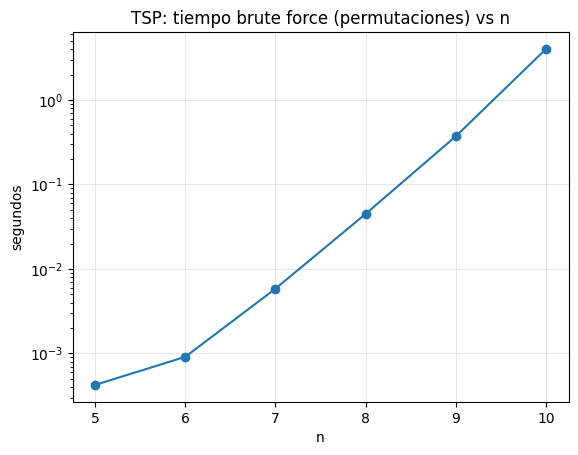

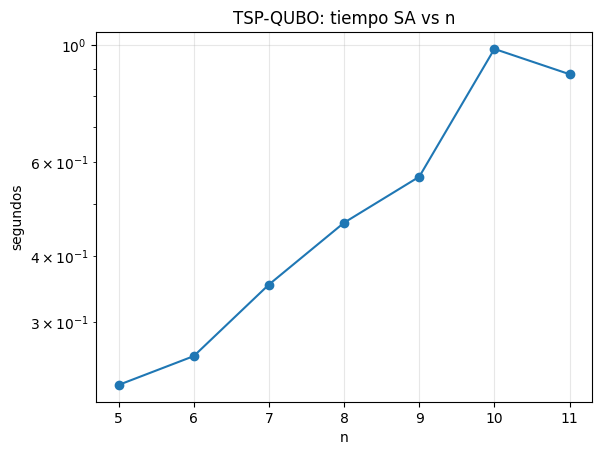

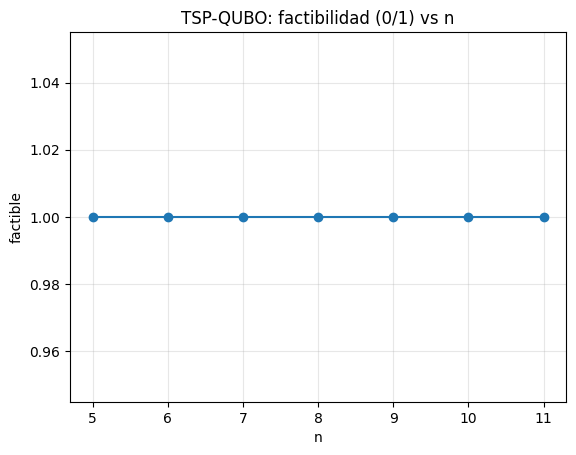

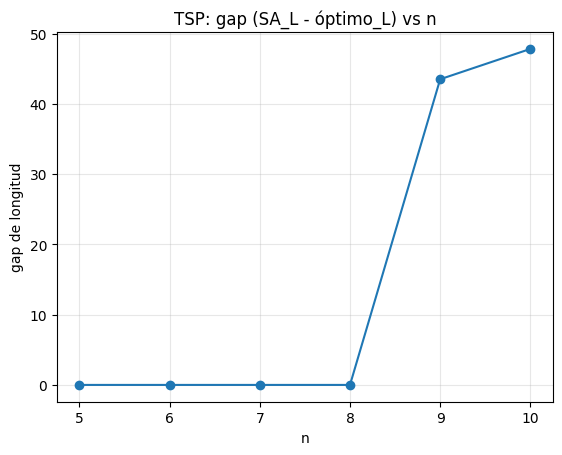

In [38]:
ns = [r["n"] for r in res_tsp]

bf_ns = [r["n"] for r in res_tsp if r["bf_time"] is not None]
bf_t  = [r["bf_time"] for r in res_tsp if r["bf_time"] is not None]
plot_curve(bf_ns, bf_t, "TSP: tiempo brute force (permutaciones) vs n", "n", "segundos", logy=True)

sa_t = [r["sa_time"] for r in res_tsp]
plot_curve(ns, sa_t, "TSP-QUBO: tiempo SA vs n", "n", "segundos", logy=True)

feas = [1 if r["sa_feasible"] else 0 for r in res_tsp]
plot_curve(ns, feas, "TSP-QUBO: factibilidad (0/1) vs n", "n", "factible")

gap_ns = [r["n"] for r in res_tsp if r["gap_L"] is not None]
gaps = [r["gap_L"] for r in res_tsp if r["gap_L"] is not None]
plot_curve(gap_ns, gaps, "TSP: gap (SA_L - óptimo_L) vs n", "n", "gap de longitud")


In [39]:
def tsp_lambda_sweep(n=8, lambda_list=(10,50,100,200,400,800), num_reads=1500, seed=0):
    coords = crear_ciudades(n, seed=seed)
    D = matriz_distancias(coords)

    rows = []
    for lam in lambda_list:
        out, dt = timed_call(sa_tsp_qubo, D, lam, lam, num_reads, seed + int(lam))
        rows.append({
            "lambda": lam,
            "time": dt,
            "feasible": out["feasible"],
            "L": out["L"]
        })
    return D, coords, rows

D8, coords8, lam_rows = tsp_lambda_sweep()
lam_rows


[{'lambda': 10, 'time': 5.9305939999976545, 'feasible': np.False_, 'L': None},
 {'lambda': 50, 'time': 1.8342854000002262, 'feasible': np.False_, 'L': None},
 {'lambda': 100,
  'time': 0.9203698999990593,
  'feasible': np.True_,
  'L': 321.2316103695901},
 {'lambda': 200,
  'time': 0.6076662999985274,
  'feasible': np.True_,
  'L': 334.93240543089706},
 {'lambda': 400,
  'time': 0.405437699999311,
  'feasible': np.True_,
  'L': 335.31340151927867},
 {'lambda': 800,
  'time': 0.40852669999731006,
  'feasible': np.True_,
  'L': 335.31340151927867}]

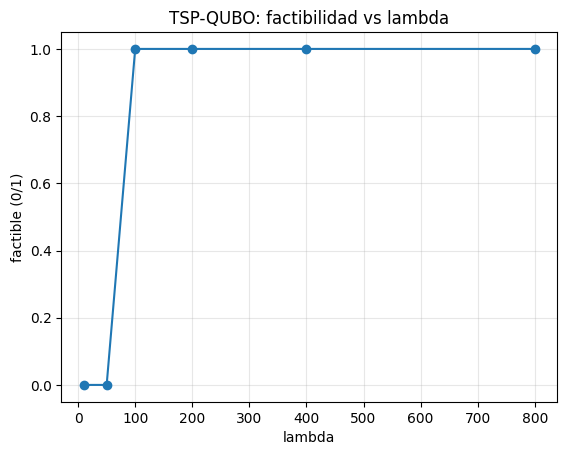

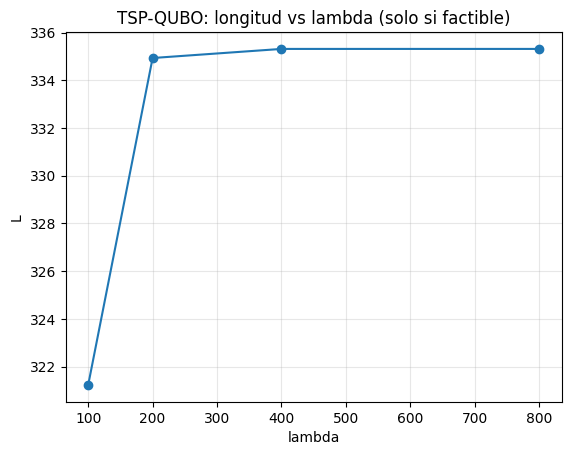

In [40]:
lams = [r["lambda"] for r in lam_rows]
feas = [1 if r["feasible"] else 0 for r in lam_rows]
plot_curve(lams, feas, "TSP-QUBO: factibilidad vs lambda", "lambda", "factible (0/1)")

L_vals = [r["L"] if r["L"] is not None else np.nan for r in lam_rows]
plot_curve(lams, L_vals, "TSP-QUBO: longitud vs lambda (solo si factible)", "lambda", "L")
